In [1]:
# -----------------------------
# 1. Imports and Setup
# -----------------------------
import os, shutil, random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Setup complete, using device:", device)


✅ Setup complete, using device: cuda


In [9]:
# -----------------------------
# 2. Preprocessing (Stronger Augmentation)
# -----------------------------
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),   # replicate grayscale into RGB
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet RGB means
        std=[0.229, 0.224, 0.225]
    )
])


# -----------------------------
# 3. Download the FASHIONMNIST train and test datasets
# -----------------------------

In [10]:
# -----------------------------
# 3. Download the FASHIONMNIST train and test datasets
# -----------------------------
train_data = torchvision.datasets.MNIST(root = './data', train =  True, download = True, transform = transform)
test_data = torchvision.datasets.MNIST(root = './data', train =  False, download = True, transform = transform)

In [11]:

# -----------------------------
# 4. Split train into train + validation
# -----------------------------

train_size = int(0.8 * len(train_data))   # 80% for training
val_size = len(train_data) - train_size   # 20% for validation

train_data, val_data = torch.utils.data.random_split(
    train_data, [train_size, val_size]
)

print(f"Train samples: {len(train_data)}, Val samples: {len(val_data)} , Test samples: {len(test_data)}")


Train samples: 48000, Val samples: 12000 , Test samples: 10000


In [13]:
#Check the shape of the first image tensor of train dataset
train_data[0][0].shape

torch.Size([3, 128, 128])

In [20]:
# -----------------------------
# 5. Load the data in batches
# -----------------------------
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data, batch_size=64, shuffle=False, num_workers=2)
test_loader   = DataLoader(test_data, batch_size=64, shuffle=False, num_workers=2)


In [19]:
import numpy as np

# train_dataset and val_dataset are Subset objects
train_labels = np.unique([train_data.dataset.targets[i].item() for i in train_data.indices])
val_labels   = np.unique([val_data.dataset.targets[i].item() for i in val_data.indices])
test_labels  = np.unique(test_data.targets.numpy())

print("Train classes:", train_labels)
print("Val classes:", val_labels)
print("Test classes:", test_labels)


Train classes: [0 1 2 3 4 5 6 7 8 9]
Val classes: [0 1 2 3 4 5 6 7 8 9]
Test classes: [0 1 2 3 4 5 6 7 8 9]


In [21]:

# -----------------------------
# 6. Model Setup (ResNet18 + Dropout Head)
# -----------------------------
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(resnet.fc.in_features, 10)
)
resnet = resnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

print("✅ Model ready with Augmentation + Dropout + Weight Decay + Scheduler")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


✅ Model ready with Augmentation + Dropout + Weight Decay + Scheduler


In [22]:
# -----------------------------
# 7. Training Loop (20 epochs)
# -----------------------------
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=20):
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

        train_acc = 100.0 * correct / total
        print(f"Train Loss: {running_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}%")

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, preds = outputs.max(1)
                correct += preds.eq(labels).sum().item()
                total += labels.size(0)

        val_acc = 100.0 * correct / total
        print(f"Val Acc: {val_acc:.2f}%")

        scheduler.step()


In [25]:
# -----------------------------
# 8. Train
# -----------------------------
train_model(resnet, train_loader, val_loader, criterion, optimizer, scheduler, epochs=4)





Epoch 1/4
Train Loss: 0.0235, Train Acc: 99.27%
Val Acc: 99.03%

Epoch 2/4
Train Loss: 0.0233, Train Acc: 99.28%
Val Acc: 99.04%

Epoch 3/4
Train Loss: 0.0227, Train Acc: 99.28%
Val Acc: 99.01%

Epoch 4/4
Train Loss: 0.0220, Train Acc: 99.32%
Val Acc: 98.97%


In [26]:
# ✅ Save only the state dict (recommended)
torch.save(resnet.state_dict(), "/content/drive/MyDrive/resnet18_fashionMNIST_state_dict.pth")

# ✅ Save the entire model object (quick but less portable)
torch.save(resnet, "/content/drive/MyDrive/resnet18_fashionMNIST_full_model.pth")
print("Model and weights saved in drive ")


Model and weights saved in drive 


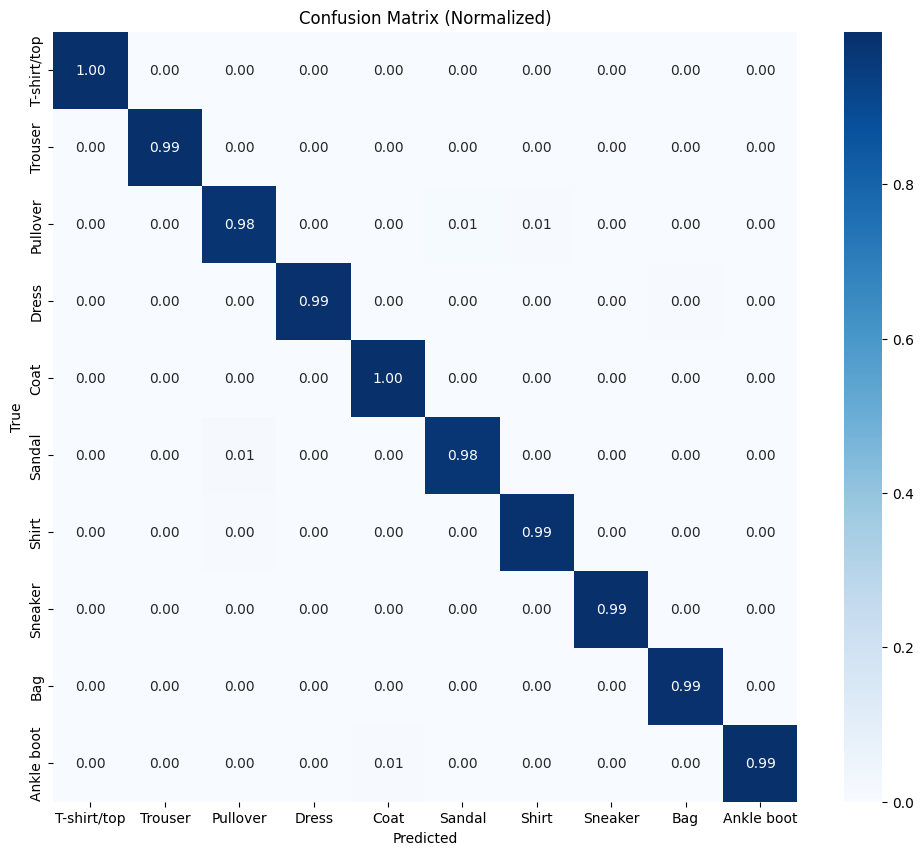


Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       1.00      1.00      1.00      1212
     Trouser       1.00      0.99      1.00      1308
    Pullover       0.98      0.98      0.98      1221
       Dress       1.00      0.99      0.99      1255
        Coat       0.99      1.00      0.99      1137
      Sandal       0.98      0.98      0.98      1077
       Shirt       0.99      0.99      0.99      1241
     Sneaker       0.99      0.99      0.99      1227
         Bag       0.99      0.99      0.99      1146
  Ankle boot       0.99      0.99      0.99      1176

    accuracy                           0.99     12000
   macro avg       0.99      0.99      0.99     12000
weighted avg       0.99      0.99      0.99     12000



In [29]:
# -----------------------------
# 9. Confusion Matrix + Per-Class Metrics
# -----------------------------
def evaluate_with_confusion(model, loader, classes):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:   # use the loader passed in
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix (Normalized)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=classes))

# -----------------------------
# Run on validation set
# -----------------------------
# For FashionMNIST, use built-in class names
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

evaluate_with_confusion(resnet, val_loader, class_names)


In [30]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 69.2 MB/s eta 0:00:00


In [49]:
import torch
import torch.nn as nn
from torchvision import models
import faiss
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# 1. Load Fine-tuned ResNet18
# -----------------------------
num_classes = 10  # FashionMNIST has 10 classes (adjust if different)
resnet = models.resnet18(weights=None)   # don't load default ImageNet weights
resnet.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(resnet.fc.in_features, num_classes)
)

# Load your fine-tuned weights (state_dict)
checkpoint_path = "/content/drive/MyDrive/resnet18_fashionMNIST_state_dict.pth"
resnet.load_state_dict(torch.load(checkpoint_path, map_location=device))

resnet = resnet.to(device)
resnet.eval()

# -----------------------------
# 2. Embedding Model (remove classifier head)
# -----------------------------
embedding_model = nn.Sequential(*list(resnet.children())[:-1])  # cut off FC
embedding_model = embedding_model.to(device)
embedding_model.eval()

# -----------------------------
# 3. Embedding Function
# -----------------------------
def get_embedding(imgs):
    with torch.no_grad():
        emb = embedding_model(imgs.to(device))   # [batch, 512, 1, 1]
        emb = torch.flatten(emb, 1)              # [batch, 512]
    return emb

# -----------------------------
# 4. Build FAISS Index (using test_loader)
# -----------------------------
d = 512  # embedding dimension
index = faiss.IndexFlatIP(d)  # cosine similarity via inner product

all_embeddings = []
for imgs, _ in train_loader:   # use train_loader here
    emb = get_embedding(imgs)
    all_embeddings.append(emb.cpu().numpy())

all_embeddings = np.vstack(all_embeddings)
faiss.normalize_L2(all_embeddings)  # normalize for cosine similarity
index.add(all_embeddings)

print("✅ FAISS index built with", len(all_embeddings), "images")


✅ FAISS index built with 48000 images


In [50]:
# -----------------------------
# 5. Query Example
# -----------------------------
# Take one batch from test_loader
query_imgs, query_labels = next(iter(test_loader))

# Pick the first image in the batch
query_img = query_imgs[0].unsqueeze(0)   # shape [1, C, H, W]
query_label = query_labels[0].item()

# Get embedding
query_emb = get_embedding(query_img).cpu().numpy()
faiss.normalize_L2(query_emb)

# Search top-k nearest neighbors
k = 5
distances, indices = index.search(query_emb, k)

print("Query label:", query_label)
print("Top-k nearest neighbors indices:", indices[0])
print("Similarity scores:", distances[0])


Query label: 7
Top-k nearest neighbors indices: [36728 12761 43309 12679 26639]
Similarity scores: [0.9870198  0.98608863 0.9853246  0.98527604 0.9844559 ]


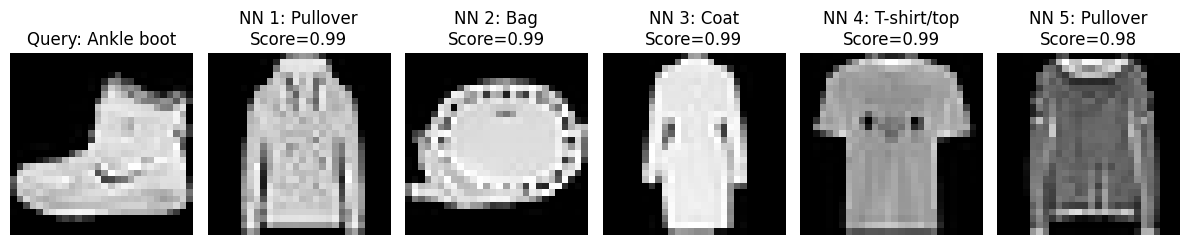

In [51]:
import matplotlib.pyplot as plt
from torchvision import datasets

# FashionMNIST class names
fashion_classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# ✅ Raw dataset (original PIL images, no transform)
fashion_raw = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=None   # returns PIL images
)

# -----------------------------
# Display Query + Neighbors (original PIL images)
# -----------------------------
plt.figure(figsize=(12, 4))

# Show query image from raw dataset
query_idx = 0   # example: first test sample
query_img, query_label = fashion_raw[query_idx]
plt.subplot(1, k+1, 1)
plt.imshow(query_img, cmap="gray")
plt.title(f"Query: {fashion_classes[query_label]}")
plt.axis("off")

# Show nearest neighbors using FAISS indices
for i, idx in enumerate(indices[0]):
    neighbor_img, neighbor_label = fashion_raw[idx]  # fetch from raw dataset
    plt.subplot(1, k+1, i+2)
    plt.imshow(neighbor_img, cmap="gray")
    plt.title(f"NN {i+1}: {fashion_classes[neighbor_label]}\nScore={distances[0][i]:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()


USE DEFAULT WEIGHTS OF RESNET18

In [45]:
import torch
import torch.nn as nn
from torchvision import models
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Load ResNet18 with DEFAULT pretrained weights
# -----------------------------
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace the classifier head for FashionMNIST (10 classes)
num_classes = 10
resnet.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(resnet.fc.in_features, num_classes)
)

resnet = resnet.to(device)
resnet.eval()

# -----------------------------
# 2. Embedding Model (remove classifier head)
# -----------------------------
embedding_model = nn.Sequential(*list(resnet.children())[:-1])  # cut off FC
embedding_model = embedding_model.to(device)
embedding_model.eval()

# -----------------------------
# 3. Embedding Function
# -----------------------------
def get_embedding(imgs):
    with torch.no_grad():
        emb = embedding_model(imgs.to(device))   # [batch, 512, 1, 1]
        emb = torch.flatten(emb, 1)              # [batch, 512]
    return emb

# -----------------------------
# 4. Build FAISS Index (using test_loader)
# -----------------------------
d = 512  # embedding dimension
index = faiss.IndexFlatIP(d)  # cosine similarity via inner product

all_embeddings = []
for imgs, _ in train_loader:   # use train_loader here
    emb = get_embedding(imgs)
    all_embeddings.append(emb.cpu().numpy())

all_embeddings = np.vstack(all_embeddings)
faiss.normalize_L2(all_embeddings)  # normalize for cosine similarity
index.add(all_embeddings)

print("✅ FAISS index built with", len(all_embeddings), "images")


✅ FAISS index built with 48000 images


In [46]:
# -----------------------------
# 5. Query Example
# -----------------------------
# Take one batch from test_loader
query_imgs, query_labels = next(iter(test_loader))

# Pick the first image in the batch
query_img = query_imgs[0].unsqueeze(0)   # shape [1, C, H, W]
query_label = query_labels[0].item()

# Get embedding
query_emb = get_embedding(query_img).cpu().numpy()
faiss.normalize_L2(query_emb)

# Search top-k nearest neighbors
k = 5
distances, indices = index.search(query_emb, k)

print("Query label:", query_label)
print("Top-k nearest neighbors indices:", indices[0])
print("Similarity scores:", distances[0])


Query label: 7
Top-k nearest neighbors indices: [20970  2150 18900 37719 18179]
Similarity scores: [0.9108044  0.89768267 0.897104   0.89580244 0.8950915 ]


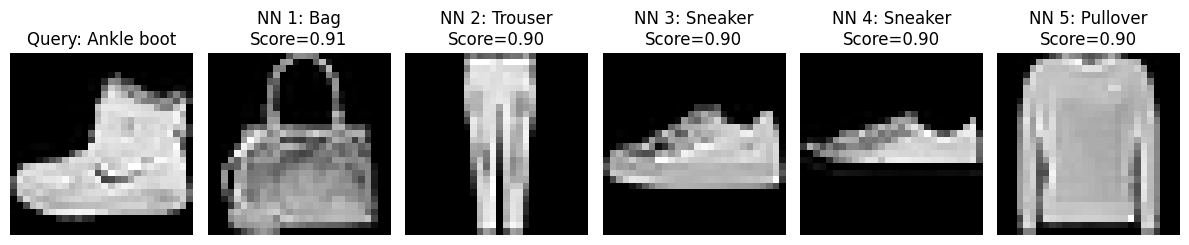

In [48]:
import matplotlib.pyplot as plt
from torchvision import datasets

# FashionMNIST class names
fashion_classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# ✅ Raw dataset (original PIL images, no transform)
fashion_raw = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=None   # returns PIL images
)

# -----------------------------
# Display Query + Neighbors (original PIL images)
# -----------------------------
plt.figure(figsize=(12, 4))

# Show query image from raw dataset
query_idx = 0   # example: first test sample
query_img, query_label = fashion_raw[query_idx]
plt.subplot(1, k+1, 1)
plt.imshow(query_img, cmap="gray")
plt.title(f"Query: {fashion_classes[query_label]}")
plt.axis("off")

# Show nearest neighbors using FAISS indices
for i, idx in enumerate(indices[0]):
    neighbor_img, neighbor_label = fashion_raw[idx]  # fetch from raw dataset
    plt.subplot(1, k+1, i+2)
    plt.imshow(neighbor_img, cmap="gray")
    plt.title(f"NN {i+1}: {fashion_classes[neighbor_label]}\nScore={distances[0][i]:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()
